# Ch06.결정 트리

**결정 트리(Decision tree)** 는 분류와 회귀 작업 그리고 다중 출력까지 가능한 다목적 머신러닝 알고리즘이다. 매우 복잡한 데이터셋도 학습할 수 있으며, 최근 자주 사용되는 강력한 알고리즘인 **앙상블(Ensemble)** 기법의 기본 구성 요소이다.

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 


from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

---

## 6.1 결정 트리 학습과 시각화

결정 트리를 이해하기 위해 모델을 만들어 어떻게 예측하는지 살펴본다. 다음은 붓꽃 데이터셋에 `DecisionTreeClassifier`를 훈련시키는 코드이다.

In [2]:
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)','petal width (cm)']].values
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2,random_state=42)
tree_clf.fit(X,y);

`plot_tree` 함수를 사용해 트리를 시각화할 수 있다.

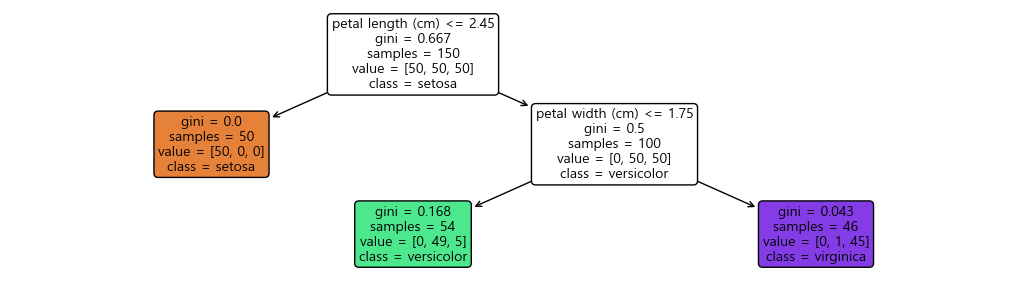

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(13, 3.5))
plot_tree(tree_clf,
          feature_names=['petal length (cm)', 'petal width (cm)'],
          class_names=iris.target_names,
          rounded = True,
          filled=True,
          fontsize=10) 
plt.show()

`export_graphviz()` 함수를 사용하여 다음과 같이 학습시킨 트리를 다양한 형식의 파일로 저장할 수 있으며, `graphviz.Source.from_file()`로 주피터 노트북에 파일을 로드하고 표시할수도 있다. `graphviz`는 오픈 소스 그래프 시각화 소프트웨어 패키지

```python
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file ='iris_tree.dot'
    feature_names = ['petal length (cm)','petal width (cm)'],
    class_names = iris.target_names,
    rounded = True,
    filled = True
)

## Loading
from graphviz import Source
Source.from_file('iris_tree.dot')

---

## 6.2 예측

<center>

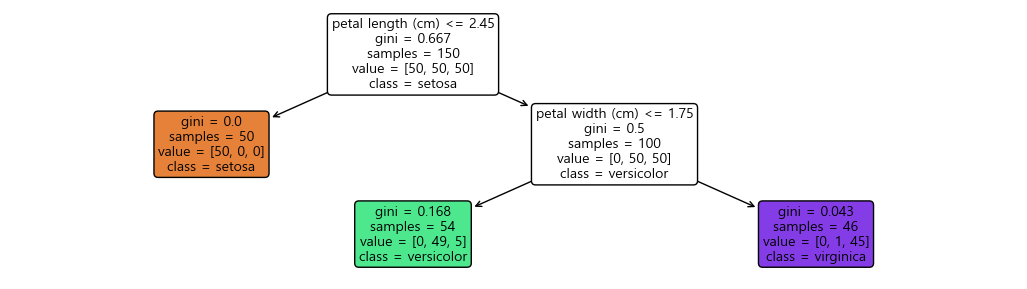

</center>

위의 트리가 어떻게 예측을 만들어내는지 살펴본다. 먼저 **루트 노드(root node)** 는 깊이가 0인 맨 꼭대기의 노드이며, 여기에서부터 시작한다. 이 노드는 꽃잎의 길이가 2.45cm보다 짧은지 확인한다. 만약 그렇다면 루트 노드에서 왼쪽의 깊이 1의 왼쪽 노드인 **자식 노드**로 이동한다. 이 경우엔 이 노드가 자식 노드가 없는  **리프 노드(leaf node)** 이므로 추가적인 분기없이 노드에 있는 예측 클래스를 보고 결정 트리가 *Iris-Setosa*라고 예측한다.

이번엔 꽃잎의 길이가 2.45cm보다 길다고 하면, 다시 루트 노드에서 시작하지만 이번에는 오른쪽 자식 노드로 이동한다. 이 노드는 리프 노드가 아니고 분할 노드이다. 따라서 추가적으로 꽃잎의 너비가 1.75cm보다 작은지 확인한다. 만약 그렇다면 이 꽃은 *Iris-Versicolor*이고, 그렇지 않다면 *Iris-Virginica*로 모델이 예측한다.

노드의 `sample` 속성은 얼마나 많은 훈련 샘플이 적용되었는지를 알려준다. 100개의 훈련 샘플의 꽃잎 길이가 2.45cm보다 길고(깊이 1 오른쪽), 그 중 54개 샘플의 꽃잎 너비가 1.75cm보다 짧다(깊이2 왼쪽).

노드의 `value` 속성은 노드에서 각 클래스에 얼마나 많은 훈련 샘플이 있는지 알려준다. 예를 들어 맨 오른쪽 아래 노드는 *Iris-Setosa*가 0개이고, *Iris-Versicolor*가 1개, *Iris-Virginica*가 45개 있다.

마지막으로 노드의 `gini` 속성은 **지니 불순도(gini impurity)** 를 측정한다. 한 노드의 모든 샘플이 같은 클래스에 속해 있다면 이 노드를 순수(`gini=0`)하다고 한다. 지니 불순도는 다음과 같다.
$$
G_i= 1-\sum_{k=1}^{n}p_{i,k}^2
$$

여기서 $G_i$는 $i$번째 노드의 지니 불순도이며, $p_{i,k}$는 $i$번째 노드에 있는 훈련 샘플 중 클래스 $k$에 속한 샘플의 비율이다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● 사이킷런의 결정 트리</strong><br>
    사이킷런은 <b>이진 트리</b>만 만드는 <b>CART(classification & regression tree)</b> 알고리즘을 사용한다. 이진 트리의 분할 노드는 항상  두 개의 자식 노드를 가진다. 트리는 다양한 알고리즘을 가지고 있으며, <b>ID3</b> 같은 알고리즘은 둘 이상의 자식 노드를 가진 결정 트리를 만들 수 있다.
    </div>

다음 그림은 이 결정 트리의 결정 경계를 보여준다.

<center>

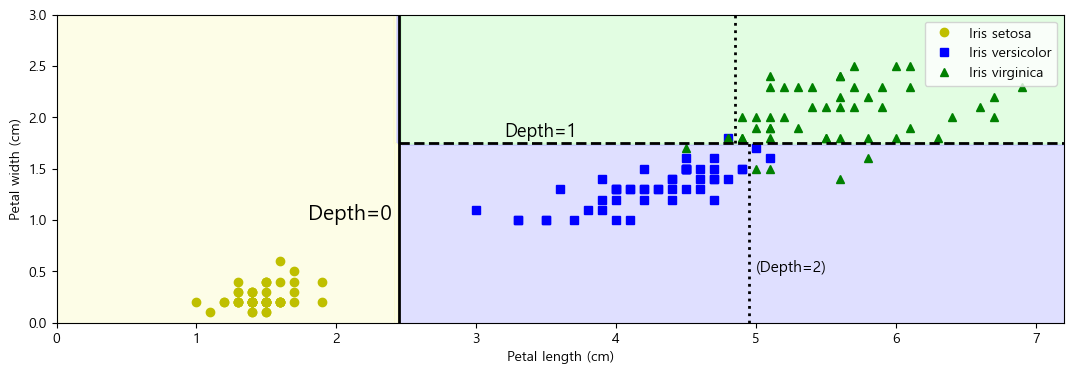

</center>

왼쪽 영역은 순수 *Iris-Setosa*만 있는 노드이기 때문에 더 나눌 필요가 없다. 하지만 오른쪽 영역은 순수한 노드가 아니므로 깊이 1의 오른쪽 노드는 꽃잎 너비 1.75cm를 기준으로 나눈다. `max_depth=3`으로 설정하면 깊이 2의 두 노드가 두 개의 수직 점선처럼 결정 경계를 추가로 만든다.

---

## 6.3 클래스 확률 추정

결정 트리는 한 샘플이 특정 클래스 $k$에 속할 확률을 추정할 수 있다. 먼저 이 샘플의 리프 노드를 찾기 위해 트리를 탐색하고 그 노드에 있는 클래스 $k$의 훈련 샘플 비율을 반환한다.

<center>

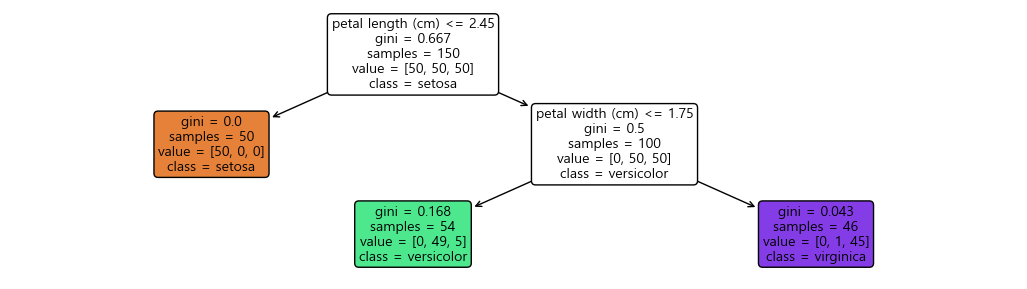

</center>

예를 들어 길이가 5cm이고 너비가 1.5cm인 꽃잎을 발견했을 때, 해당 조건에 맞는 리프 노드는 깊이 2에서 왼쪽 노드이므로 결정 트리는 그에 해당하는 확률을 출력한다. *Iris-Setosa*는 0%(0/54), *Iris-Versicolor*는 90.7%(49/54), *Iris-Virginica*는 9.3%(5/54)이다. 따라서 가장 높은 확률을 가진 *Iris-Versicolor*로 분류할 것이다.

In [4]:
print(tree_clf.predict_proba([[5,1.5]]).round(3))
print(tree_clf.predict([[5,1.5]]))

[[0.    0.907 0.093]]
[1]


---

## 6.4 CART 훈련 알고리즘

사이킷런은 결정 트리를 훈련시키기 위해 CART(Classification & Regression Tree) 알고리즘을 사용한다. 먼저 훈련 세트를 하나의 변수 $k$의 임계값 $t_k$를 사용해 두 개의 서브셋으로 나눈다(ex: 꽃잎 길이 $\ge$ $x$). $k$와 $t_k$는 크기에 따른 가중치가 적용된 가장 순수한 서브셋으로 나눌 수 있는 $(k,t_k)$ 쌍을 찾는다.

다음은 CART가 최소화하는 비용 함수이다.
$$
Loss(k,t_k)=\frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}

여기서 $G_{left/right}$는 왼쪽/오른쪽 서브셋의 불순도이며 $m_{left/right}$는 왼쪽/오른쪽 서브셋의 샘플 수이다.

즉, CART는 불순도를 가장 줄이는 $(k,t_k)$ 쌍을 찾아 분기한다. 같은 방식으로 서브셋을 나누며, 이 과정은 `max_depth` 하이퍼파라미터로 정의된 최대 깊이가 되거나 불순도를 줄이는 분할을 찾을 수 없을 때 멈추게 된다. 다른 몇 가지 파라미터들도 중지 조건에 관여한다.

여기서 알 수 있듯이 CART 알고리즘(뿐만 아니라 대부분의 트리 알고리즘들도) **탐욕적 알고리즘(Greedy algorithm)** 이다. 매번 최적의 분할을 찾으며 가장 좋은, 즉 불순도를 가장 최소화하는 분기 기준을 선택한다. 따라서 매 단계의 분할이 몇 단계를 거쳐 가장 낮은 불순도로 이어질 수 있을지 없을지는 고려하지 않는다. 탐욕적 알고리즘은 훌륭한 솔루션을 만들어내지만, 최적의 솔루션을 보장하지는 않는다.

---

## 6.5 계산 복잡도

예측을 위해서 결정 트리를 루트 노드 ~ 리프 노드까지 탐색해야 한다. 일반적으로 결정 트리는 각 경로가 비슷한 깊이를 가진, **균형적** 구조이다. 균형 이진 트리에서 깊이 $d$에서 리프 노드의 개수는 $2^d$이다. 따라서 결정 트리를 탐색하기 위해서는 약 $O(log_2(m))$개의 노드를 거쳐야 한다.

각 노드는 하나의 변수값만 확인하기 때문에 예측에 필요한 전체 복잡도는 변수의 수와 무관하게 $O(log_2(m))$이다. 그래서 큰 훈련 세트를 다룰 때도 예측 속도가 매우 빠르다.

훈련 알고리즘은 각 노드에서 모든 훈련 샘플의 모든(또는 `max_features`가 지정되었다면 그보다는 적은) 변수를 비교한다. 각 노드에서 모든 샘플의 모든 변수를 비교하면 훈련 복잡도는 $O(n \times mlog_2(m))$이 된다.

---

## 6.6 지니 불순도 VS 엔트로피

`DecisionTreeClassifier` 클래스는 지니 불순도를 낮추는 방향으로 학습하지만, `criterion='entropy'`로 지정하여 **엔트로피** 불순도를 사용할 수도 있다. 엔트로피는 분자의 무질서함을 측정하는 것으로 열역학의 개념이다. 분자가 안정되고 질서정연하면 엔트로피가 0에 가깝다. 엔트로피는 기존 열역학에서 다양한 분야에서 사용하는 개념으로 확장되었으며, **정보 이론**에서도 사용된다. 머신러닝에서는 불순도의 측정 방식으로 자주 사용된다. 어떤 세트가 한 클래스의 샘플만 담고 있다면 엔트로피는 0이다.

다음 식은 $i$번째 노드의 엔트로피이다.
$$
H_i = -\sum_{k=1}^{n}p_{i,k}log_2(p_{i,k})
$$

예를 들어 위의 `tree_clf` 모델의 깊이 2 왼쪽 노드에는 *Iris-Setosa*는 0개 *Iris-Versicolor*는 49개 *Iris-Virginica*는 5개가 있다. 따라서 해당 노드의 엔트로피는 다음과 같이 계산할 수 있다.
$$ 
-\frac{0}{54}log_2(\frac{0}{54})-\frac{49}{54}log_2(\frac{49}{54})-\frac{5}{54}log_2(\frac{5}{54}) \approx 0.445
$$

지니 불순도와 엔트로피는 실제로는 큰 차이가 없다. 지니 불순도가 조금 더 계산이 빨라 기본값으로 많이 사용된다. 하지만 지니 불순도는 가장 **빈도가 높은 클래스를 한쪽 가지로 고립시키는 경향**이 있는 반면, 엔트로피는 조금 더 균형 잡힌 트리를 만들어낸다.

---

## 6.7 규제 파라미터

결정 트리는 훈련 데이터에 대한 제약 사항이 거의 없다. 제한을 두지 않으면 트리가 훈련 데이터에 아주 가깝게 맞추려고 해서 과대적합이 발생하기 쉽다.

훈련 데이터에 대한 과대적합을 피하기 위해 학습할 때 결정 트리의 자유도를 제한할 필요가 있다. 규제 파라미터는 사용하는 알고리즘에 따라 다르지만 보통 적어도 결정 트리의 최대 깊이는 제어할 수 있다. 사이킷런에서는 `max_depth` 파라미터로 이를 조절한다. 기본값은 제한이 없는 것을 의미하는 `None`이다. `max_depth`를 줄이면 모델을 규제하게 되고 과대적합의 위험이 감소한다.

`DecisionTreeClassifier`에는 비슷하게 결정 트리의 형태를 제한하는 다른 하이퍼파라미터가 여러 개 존재한다.

- `max_features` : 각 노드에서 분할을 위해 탐색할 변수의 최대 수  

- `max_leaf_nodes` : 리프 노드의 최대 수  

- `min_samples_split` : 분할되기 위해 노드가 가져야 하는 최소 샘플 수  

- `min_samples_leaf` : 리프 노드가 생성되기 위해 가지고 있어야 할 최소 샘플 수

- `min_weight_fraction_leaf` : `min_samples_leaf`와 같지만 가중치가 부여된 전체 샘플 수에서의 비율

`min_`으로 시작하는 파라미터를 증가시키거나 `max_`로 시작하는 매개변수를 감소시키면 규제가 강해진다.

`moons` 데이터셋에서 규제를 테스트해본다. 규제 없이 결정 트리 하나를 훈련하고 `min_samples_leaf=5`로 다른 결정 트리를 훈련한다.

In [7]:
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=150,noise=0.2,random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf1.fit(X,y);

tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf2.fit(X,y);

<center>

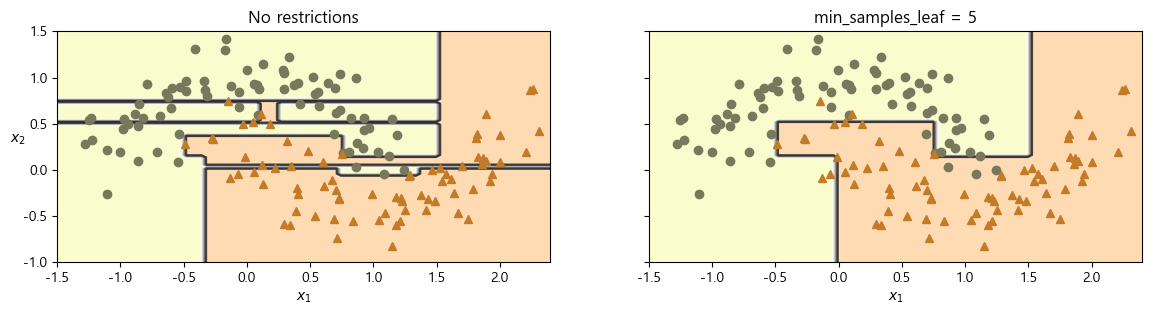

</center>

규제가 없는 왼쪽 모델은 복잡한 결정 경계를 가진 반면, 오른쪽의 규제가 있는 모델은 비교적 단순한 결정 경계를 가지고 있다. 따라서 오른쪽 모델이 일반화가 더 잘 될 것이다.

### 가지치기

제한 없이 결정 트리를 훈련시키고 불필요한 노드를 **가지치기(Pruning,제거)** 하는 알고리즘도 있다. 정확히는 사후 가지치기라고 한다. 순도를 높이는 것이 **통계적으로 큰 효과가 없다면** 리프 노드 바로 위의 노드는 불필요할 수 있다. 대표적으로 $\chi^2$ 검정 같은 통계적 검정을 사용하여 우연히 향상된 것인지 추정한다. 이 확률을 *P-value*라 부르며 임계값(일반적으로 5%)보다 높으면 그 노드는 불필요한 것으로 간주되고 자식 노드는 삭제된다. 가지치기는 불필요한 노드가 모두 없어질 때까지 계속된다.

---

## 6.8 회귀

결정 트리는 회귀에도 사용된다. 사이킷런의 `DecisionTreeRegressor`를 사용해 잡음이 섞인 2차 함수 형태의 데이터셋에서 `max_depth=2` 설정으로 회귀 트리를 만들어본다.

In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.random.rand(200,1) - 0.5
y = X ** 2 + 0.025 * np.random.randn(200,1)

tree_reg = DecisionTreeRegressor(max_depth=2,random_state=42)
tree_reg.fit(X,y);

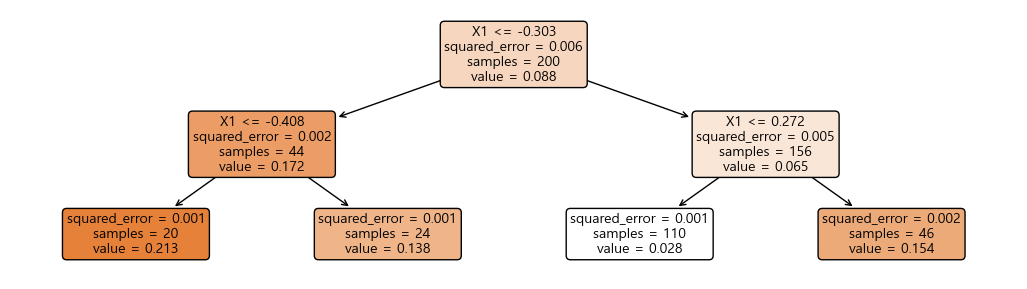

In [16]:
plt.figure(figsize=(13, 3.5))

plot_tree(tree_reg,
          feature_names=['X1'],
          fontsize=10,
          rounded=True,
          filled=True)

plt.show()

분류 나무와 비슷하지만, $MSE$를 최소화하는 분할을 탐색한다(정확히는 매 노드 분할에서 $SSE$, 제곱 오차를 줄이는 방향으로 분할을 정한다).

다음 식은 알고리즘이 훈련 과정에서 사용하는 비용 함수이다.
$$
Loss(k,t_k)=\frac{m_{left}}{m}MSE_{left}+\frac{m_{right}}{m}MSE_{right}
$$

$$
MSE_{node} = \frac{1}{m_{node}}\sum_{i \in node}^{}(\hat{y}_{node}-y^{(i)})^2

여기서 $MSE_{node} = \frac{1}{m_{node}}\sum_{i \in node}^{}(\hat{y}_{node}-y^{(i)})^2$, $\hat{y}_{node}=\frac{1}{m_{node}}\sum_{i \in node}^{}y^{(i)}$이다.

회귀에서도 결정 트리가 과대적합되기 쉽다.

<center>

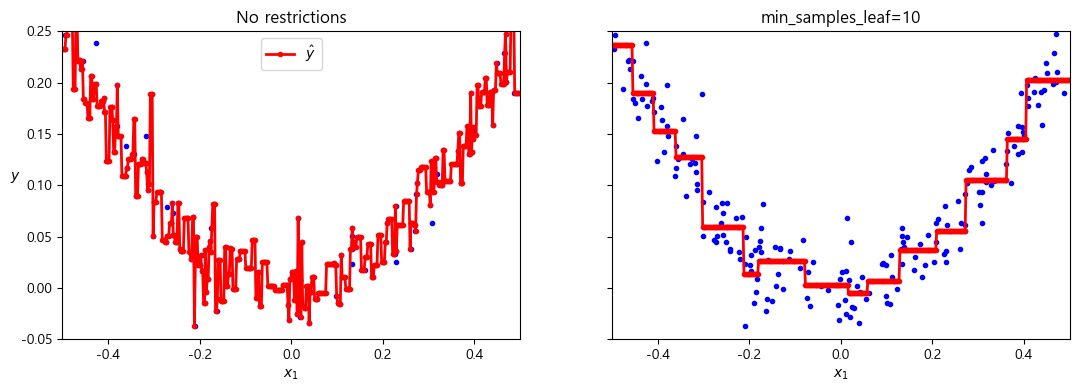

</center>

규제가 없다면 위의 그림의 왼쪽 그래프와 같이 훈련 세트에 과적합된 예측을 하게 된다. `min_samples_leaf=10`로 지정하면 오른쪽 그래프처럼 일반화된 모델을 만들 수 있다.

---

## 6.9 결정 트리의 문제점

결정 트리는 비교적 이해하고 해석하기 쉬우며, 성능도 뛰어나다. 하지만 몇 가지 제한 사항과 문제점이 있다.

### 축 방향에 대한 민감성

결정 트리는 계단 모양의 결정 경계를 만든다. 즉, **모든 분할은 축에 수직**이다. 그래서 데이터의 방향에 민감하다.

<center>

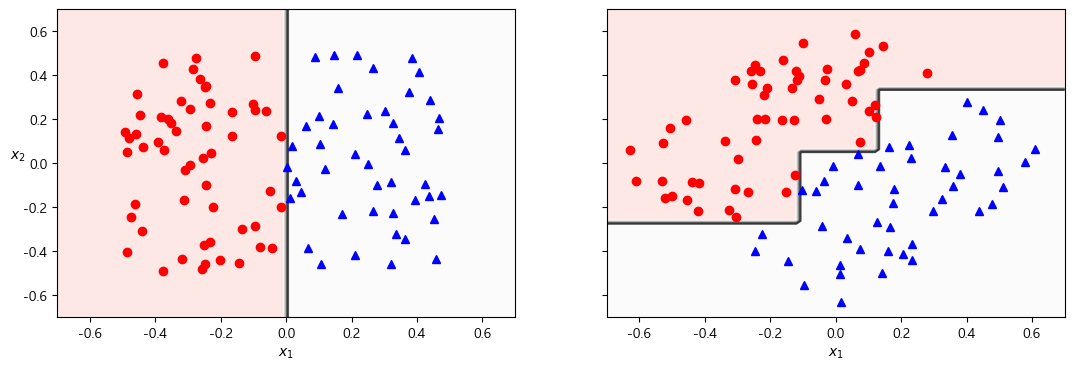

</center>

다음 그래프는 선형적으로 분류할 수 있는 두 데이터셋이지만, 왼쪽의 결정 트리는 한번의 분할로 쉽게 데이터를 분류하지만, 오른쪽의 결정 트리는 그보다 많은 분할이 필요하다.

이 문제를 완화하는 방법으로, 데이터의 스케일을 조정한 다음 **주성분 분석(PCA)** 변환을 적용하는 것이다. PCA는 변수 간의 상관관계를 줄이는 방식으로 데이터를 회정하여 결정 트리를 더 쉽게 만들 수 있다(항상 적용되는 것은 아니다).

데이터의 스케일을 조정하고 PCA를 사용하여 데이터를 회전시키는 파이프라인을 만들고, `DecisionTreeClassifier` 모델을 학습시킨다.

In [24]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)','petal width (cm)']].values
y = iris.target


pca_pipeline = make_pipeline(StandardScaler(),PCA())
X_tf = pca_pipeline.fit_transform(X)

tree_clf_pca = DecisionTreeClassifier(max_depth=2,random_state=42)
tree_clf_pca.fit(X_tf,y);

<center>

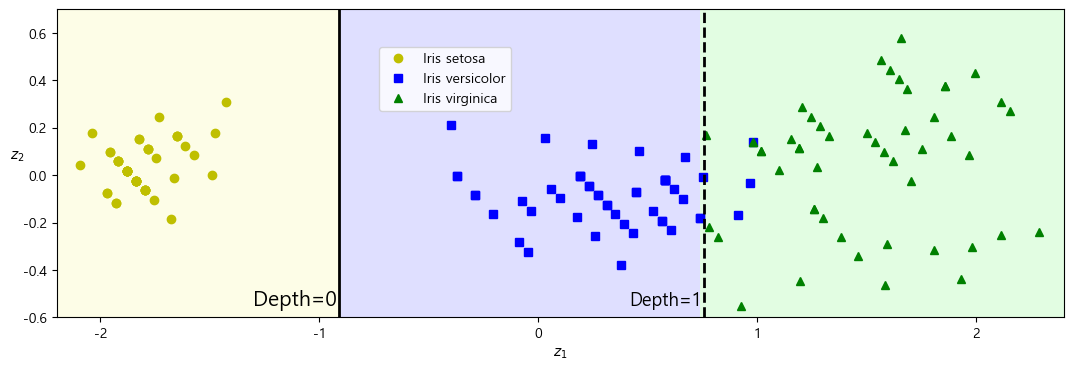

<center>

### 큰 분산 문제

일반적으로 결정 트리의 가장 주요한 문제는 **분산이 상당히 크다는 것**이다. 하이퍼파라미터나 데이터를 조금만 변경해도 매우 다른 모델이 생성될 수 있다. 사이킷런의 훈련 알고리즘은 `max_features`을 지정하면 각 노드에서 평가할 변수의 집합을 랜덤으로 선택하는 확률적인 알고리즘이며, `random_state` 파라미터를 설정하지 않으면 동일한 데이터에서 동일한 결정 트리를 재훈련하더라도 매우 다른 모델이 생성돤다.

여러 결정 트리의 예측을 합쳐 사용하는 방식을 사용하면 분산을 줄일 수 있다. 이렇게 여러 결정 트리의 예측을 합쳐 사용하는 방식을 **앙상블 기법** 중 랜덤 포레스트가 있다.